In the world of data science, data is called "new oil", but raw data is often not as neat and usable as one might expect. In reality, we often encounter missing values, duplicate records, inconsistent formats, abnormal data and even error messages. If these "dirty data" are directly used for analysis or modeling without processing, it may lead to distorted results and even affect the accuracy of decision-making.
This is where the value of Data Wrangling lies - through a systematic approach, it cleans, transforms and integrates disordered raw data, ultimately forming structured and analyzable data sets. Data organization is not only the first step in the data science process, but also the cornerstone of the success of the entire analysis and modeling.ed 

### **Data Collection**
Data collection is the systematic process of gathering information from various sources to answer research questions, solve problems, and support decision-making. There are serveral methods of data collection:

- Interviews
- Questionnaires
- Observations
- Experiments
- Published Sources and Unpublished Sources

### **Data Acquisition**
Data Acquisition refers to the process of collecting and importing raw data from various sources into the analytical environment.
These data may come from:

- Local files(such as.csv,.xlsx,.json)
- Databases(such as MySQL, SQLite, PostgreSQL)
- Online APIs(such as Twitter API, OpenWeather API)
- Web Scrap
- Open data platforms(such as Kaggle, UCI, government data portal)

In the context of Data Wrangling, the goal of data acquisition is not to build a model, but to ensure that the data is imported correctly and completely, laying a solid foundation for subsequent cleaning and analysis.

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
titanic_data = pd.read_csv("Dataset/titanic/test.csv")
titanic_data.head()
#titanic_data.tail() 
#titanic_data.describe()
#titanic_data.info()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### **Data Cleaning**
Data Cleaning refers to the process of identifying and correcting errors, omissions, duplications and inconsistencies in data to make the data more accurate, complete and usable.
In the real world, raw data is almost never clean.
It may come from different systems, manual input, web crawler collection or sensor devices, and thus often contains various problems, such as:

- Missing Values
- Duplicate Records
- Outliers
- Inconsistent Formats
- Wrong Data Types

The goal of data cleaning is:

- Retain data to the greatest extent possible;
- Ensure the accuracy and consistency of data;
  
Lay a solid foundation for subsequent analysis and modeling.

|Error type| Example|Common reason|Solution|
| ---------| -------| ----------- | -------|
|Missing Values|'Score' for some students is empty|The data was not filled in and was collected incorrectly|Delete, Fill, Interpolate|
|Duplicate Data|Same data appears multiple times|Data import/merge error|Deduplication|
|Outliers|'Socre'=999, 'Age'=-5|Input incorrect or extreme values|Modification/Delet3|
|Inconsistent Formatting |"Male", "male", "M"|Manual input is not uniform|Standlization|
|Data Type Error|'Date' is string| Reading format error|Convert data type|
|Invalid Values|'Age'='300'| System error|Check and eliminate|
.

In [2]:
titanic_data.info() # Check overall information
titanic_data.isnull().sum() # Check the number of null value of whole dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

#### Methods for Missing Value

In [3]:
# 1. If some columns or rows have too many missing values, we can delete these columns and rows
#titanic_data = titanic_data.dropna() # Rows
#titanic_data = titanic_data.dropna(axis=1) # Columns
# 2. Fill in the missing values
# Filled by mean value
titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Age'].mean())
# Filled by median value
#titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Age'].mode()[0])
# Filled by the string defined
titanic_data['Cabin'] = titanic_data['Cabin'].fillna('Unknown')
titanic_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Unknown,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,Unknown,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Unknown,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,Unknown,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,Unknown,S


#### Methods for Duplicate Value

In [4]:
print("The duplicated value number in column 'Embarked' is", titanic_data.duplicated(subset=['Embarked']).sum())
print()
duplicate_col = titanic_data['Embarked']
duplicate_col = duplicate_col.dropna() # Delte the row with missing value
print(duplicate_col.value_counts())
duplicate_col = duplicate_col.drop_duplicates()# Delte the row with the duplicated values
print(duplicate_col.value_counts())

The duplicated value number in column 'Embarked' is 415

Embarked
S    270
C    102
Q     46
Name: count, dtype: int64
Embarked
Q    1
S    1
C    1
Name: count, dtype: int64


#### Methods for outliers

<Axes: xlabel='Age'>

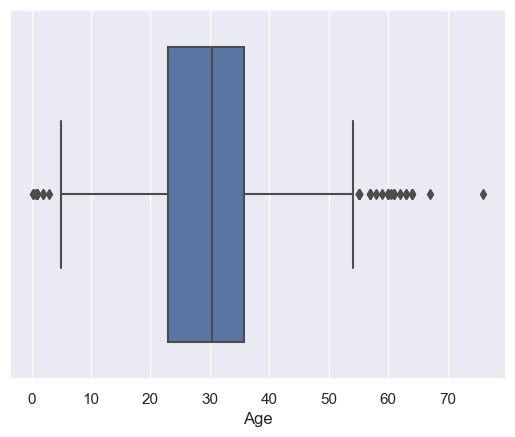

In [5]:
# Identify the outliers by visualization (Box plot)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
sns.boxplot(data = titanic_data, x = 'Age')

In [6]:
# Handling outliers by IQR(Interquartile Range)
Q1 = titanic_data['Age'].quantile(0.25)
Q3 = titanic_data['Age'].quantile(0.75)
IQR = Q3 - Q1
outlier_col = titanic_data[(titanic_data['Age'] >= Q1 - 1.5 * IQR) & (titanic_data['Age'] <= Q3 + 1.5 * IQR)]

**Z-score in Outlier Detection** 

Z-scores help standardize data and allow us to compare values from different distributions on a common scale. In the context of **outlier detection**, a Z-score quantifies how extreme a value is relative to the overall data distribution.  

For data that approximately follows a **normal distribution**, about **99.7%** of the values fall within three standard deviations from the mean ($|Z| < 3$). Therefore, any observation with an absolute Z-score greater than 3 (i.e., $|Z| > 3$) is typically considered an **outlier**, as it lies far from the majority of the data points.  

However, traditional Z-scores are **sensitive to extreme values** — since both the mean and standard deviation can be heavily influenced by outliers, this method may sometimes misclassify data points or fail to detect subtle anomalies.  

To overcome this limitation, analysts often use the **Robust Z-score**, which replaces the mean and standard deviation with more resistant statistics — the **median** and **Median Absolute Deviation (MAD)**:  

$$
Z_{robust} = \frac{X - median(X)}{1.4826 \times MAD}
$$
$$
MAD = median(|X - median(X)|)
$$

The Robust Z-score is less affected by extreme observations and performs better on **non-normally distributed or skewed data**. It provides a more reliable and stable measure of deviation, making it particularly useful in domains such as **finance**, **healthcare**, and **sensor data analysis**, where outliers are common but meaningful patterns must be preserved.  

In [7]:
# Handling outliers by Z-Score
from scipy import stats
z_scores = stats.zscore(titanic_data['Age'])
abs_z_scores = np.abs(z_scores)
filtered_entries = (abs_z_scores < 3)
outlier_col_z = titanic_data[filtered_entries]

#### Methods for Inconsistent Formatting

In [8]:
# 1. Standardizing text case
stand_case = titanic_data['Sex']
#stand_case_u = stand_case.str.upper()
#stand_case_l = stand_case.str.lower()
stand_case_s = stand_case.str.capitalize()
print(stand_case_s)

0        Male
1      Female
2        Male
3        Male
4      Female
        ...  
413      Male
414    Female
415      Male
416      Male
417      Male
Name: Sex, Length: 418, dtype: object


In [9]:
# 2. Handling Space
no_space = titanic_data['Name']
no_space = no_space.str.strip() # remove leading/trailing whitespace
#no_space = no_space.str.replace(" ", new) # or replace interval whitespace or special characters by new string

In [10]:
# 3. Standardizing Dates
import dateparser
sd_date = pd.DataFrame({'Date': ['01/02/2023', 'February 1, 2023', '2/1/23']})
sd_date['Date'] = sd_date['Date'].apply(lambda x: dateparser.parse(x))
sd_date['Date'] = sd_date['Date'].dt.strftime('%Y-%m-%d')
print(sd_date)

         Date
0  2023-01-02
1  2023-02-01
2  2023-02-01


#### Methods for the Values in Valid Range

In [11]:
valid_titanic = titanic_data[
    (titanic_data['Pclass'].isin([1, 2, 3])) &
    (titanic_data['Age'].between(1, 100))
]
print(titanic_data['Age'].min())
print(valid_titanic['Age'].min())

0.17
1.0


### **Data Transformation**

Data Transformation refers to converting data from one format or structure to another form that is more suitable for analysis.
In actual projects, the original data often has the following problems:

- The dimensions of each variable are different (for example, income is measured in US dollars and age in years);
- There are different data types such as category type, text type, and date type;
- The data distribution is unbalanced or seriously skewed.
  
Through reasonable transformation, we can enable the model to better understand the data, improve accuracy and reduce bias.

#### *Normalization*

Normalization is a technique that rescales numerical features into a fixed range—most commonly **[0, 1]**. Its main purpose is to place different features on a comparable scale, preventing large-magnitude variables from dominating distance calculations or gradient updates during model training. In real-world datasets, feature ranges often vary widely (e.g., *age* ranges from 18–60, while *income* may span thousands to hundreds of thousands). Without normalization, algorithms such as KNN, K-Means, and neural networks may produce biased or unstable results.

The most widely used method is **Min–Max Scaling**, defined as:

$$
x_{\text{norm}} = \frac{x - \text{min}}{\text{max} - \text{min}}
$$

This transformation maps the minimum value of a feature to 0, the maximum value to 1, and linearly scales all other values in between. It preserves the relative ordering of data while ensuring all features share the same numerical range.

Normalization is especially beneficial for:

- Distance-based models (KNN, K-Means)  
- Gradient-based models (neural networks)  
- Visualizations requiring comparable feature scales  

However, Min–Max Scaling is **highly sensitive to outliers**. A single extreme value can significantly stretch the range, causing most data points to compress toward zero. Therefore, outlier detection and handling are recommended before applying normalization.

In practice, normalization is typically implemented using tools like `MinMaxScaler` from scikit-learn. Importantly, in machine learning workflows, the scaler must be **fit only on the training set**, then applied to both training and test sets to avoid data leakage.

Overall, normalization is a simple yet essential preprocessing step. By bringing features to a common scale, it improves model stability, speeds up training, and enhances the quality of downstream analysis and predictions.


In [12]:
from sklearn.preprocessing import MinMaxScaler

numerical_cols = ["Age", "Fare"]
df_nor = titanic_data[numerical_cols]

# Normalize using MinMaxScaler
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df_nor),
    columns=numerical_cols
)

print(df_normalized.head())

        Age      Fare
0  0.452723  0.015282
1  0.617566  0.013663
2  0.815377  0.018909
3  0.353818  0.016908
4  0.287881  0.023984


#### *Standardization*

Standardization, also known as Z-score scaling, transforms numerical features so that they have a **mean of 0** and a **standard deviation of 1**. Unlike normalization, which rescales values into a fixed range such as [0, 1], standardization focuses on the distribution of the data. This makes it particularly useful when features vary widely in scale or when models assume normally distributed inputs.

Standardization is defined using the Z-score formula:

$$
Z = \frac{X - \mu}{\sigma}
$$

where $X$ is the raw value, $\mu$ is the mean of the feature, and $\sigma$ is its standard deviation. After transformation, most values lie roughly within the range of **[-3, 3]**, and the relative shape of the original distribution is preserved.

This scaling method is especially beneficial for algorithms that rely on distances, gradients, or variance structure, such as:

- Linear/Logistic Regression  
- KNN and K-Means  
- PCA and other dimensionality reduction techniques  
- Neural networks with gradient-based optimization  

Compared to Min–Max scaling, standardization is **less sensitive to outliers**, since extreme values do not compress the entire feature range. However, if the dataset contains substantial outliers, using a more robust variant such as `RobustScaler` may be appropriate.

In practice, standardization is most commonly implemented using scikit-learn’s `StandardScaler`. As with normalization, the scaler should be **fit on the training set only**, and then applied consistently across training, validation, and test data to prevent information leakage.

Overall, standardization is one of the most widely used preprocessing techniques in machine learning. By transforming features to a comparable distribution, it stabilizes optimization, improves model performance, and ensures that no single feature dominates due to scale differences.


In [13]:
from sklearn.preprocessing import StandardScaler

df_stand = titanic_data[numerical_cols]

# Standardize using StandardScaler
scaler = StandardScaler()
df_standardized = pd.DataFrame(
    scaler.fit_transform(df_stand),
    columns=numerical_cols
)

print(df_standardized.head())

        Age      Fare
0  0.334993 -0.497811
1  1.325530 -0.512660
2  2.514175 -0.464532
3 -0.259330 -0.482888
4 -0.655545 -0.417971


#### *Log Transformation*

Log transformation is a widely used technique for handling numerical features that exhibit strong right-skewness or long-tailed distributions. Many real-world variables — such as income, ticket fare, sales amounts, house prices, medical costs, and population counts — contain a small number of extremely large values and a large number of relatively small values. This imbalance can distort statistical analysis and negatively affect machine learning models, especially those that rely on assumptions of normality, uniform variance, or distance-based metrics.

The core idea of log transformation is to compress large values while expanding the relative differences among smaller ones. By applying a logarithmic scale, the distribution becomes more symmetric and closer to a normal distribution, which often leads to improved model performance and more interpretable relationships. The transformation is typically implemented using the natural logarithm:

$$
x_{\text{log}} = \log(1 + x)
$$

The use of $log(1 + x)$ — commonly implemented as `np.log1p()` — avoids undefined values when \(x = 0\), and provides a numerically stable way to apply a log transform across a wide range of values. Through this transformation, extreme outliers no longer dominate the feature scale, and variance becomes more consistent across the dataset. As a result, linear models may capture relationships more effectively, residual variance becomes more stable, and downstream learning algorithms can operate under more favorable numeric conditions.

Log transformation is particularly beneficial when:

- A feature has heavy **right skew** or extreme outliers that distort the scale  
- Differences between small values are more meaningful than differences between large values  
- Linear relationships are obscured by exponential or multiplicative growth patterns  
- Variance needs to be stabilized to satisfy modeling assumptions (e.g., in regression) 

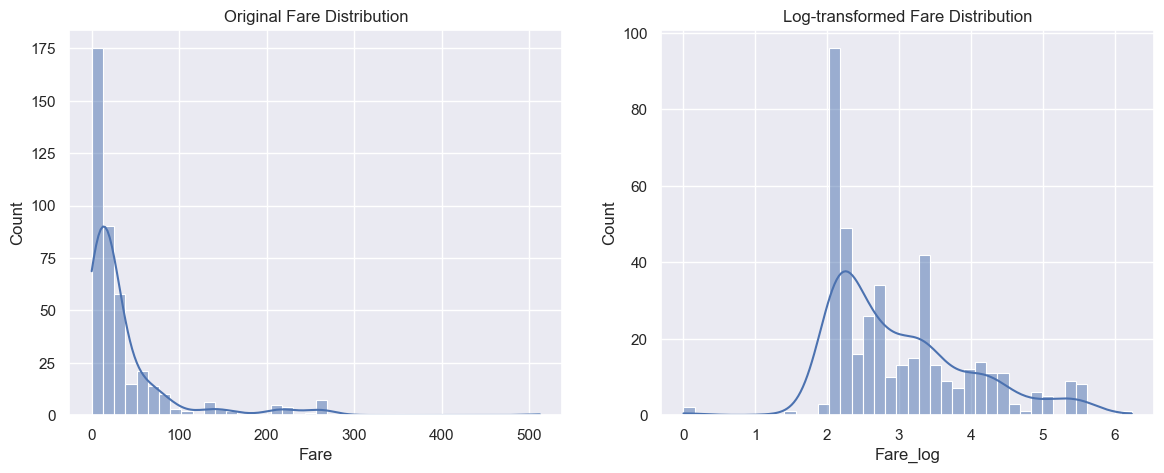

In [14]:
titanic_data["Fare_log"] = np.log1p(titanic_data["Fare"])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(titanic_data["Fare"], kde=True, bins=40)
plt.title("Original Fare Distribution")

plt.subplot(1, 2, 2)
sns.histplot(titanic_data["Fare_log"], kde=True, bins=40)
plt.title("Log-transformed Fare Distribution")

plt.show()

#### *Categorical Encoding*

Categorical encoding refers to the set of techniques used to convert categorical (non-numeric) variables into numerical representations that machine learning models can interpret. Many real-world datasets contain features such as gender, cabin class, city, education level, or occupation, all of which carry meaningful information but cannot be directly used in mathematical models. Categorical encoding ensures that these features are translated into numerical form while preserving their structure and preventing the introduction of artificial relationships.

The most widely used approach is **One-Hot Encoding**, which creates a binary column for each category and assigns a value of 1 or 0 to indicate membership. For example, a “Sex” feature with values `male` and `female` becomes two columns `[male, female]`, allowing models to treat categories as independent without implying any ordinal relationship. This method works well for linear models, logistic regression, neural networks, and any algorithm that assumes all features contribute independently. However, one-hot encoding can lead to extremely high-dimensional data when a feature contains many unique categories, a problem known as the “curse of dimensionality.”

Another common method is **Label Encoding**, which assigns an integer to each category (e.g., `First = 0`, `Second = 1`, `Third = 2`). It is simple and does not increase dimensionality, making it highly compatible with tree-based models such as decision trees, random forests, XGBoost, and LightGBM. These models do not interpret numeric differences as ordinal relationships, so the encoded integers do not introduce bias. However, for linear models or distance-based models, label encoding can be misleading, as the numerical mapping implies an order that may not exist.

A more advanced technique is **Target Encoding**, where each category is replaced by the average value of the target variable for that category. For example, in survival prediction, the “Embarked” feature may be encoded using the survival rate for passengers who embarked at each port. Target encoding is particularly powerful for high-cardinality features, but it requires careful regularization to avoid overfitting, especially when categories have small sample sizes. Techniques such as smoothing, adding noise, or using cross-validation folds are often applied to mitigate this risk.

Choosing the appropriate encoding method depends on both the properties of the categorical feature and the type of model being used. One-hot encoding is the safest and most general-purpose choice, while label encoding is ideal for tree-based algorithms. Target encoding is typically reserved for advanced modeling scenarios where maximizing predictive performance is crucial, and careful handling of overfitting is possible. Regardless of the method, categorical encoding is a fundamental step in transforming raw data into a form that machine learning algorithms can effectively learn from.


#### *Binning / Discretization*

Binning, also known as discretization, is a technique used to convert continuous numerical features into discrete categorical intervals. Instead of treating each numeric value as its own unique quantity, binning groups ranges of values together, allowing models to capture broader trends and reduce the impact of noise or outliers. Many real-world features—such as age, income, transaction amounts, or time durations—can benefit from being represented as meaningful intervals rather than raw continuous numbers.

The primary purpose of binning is to simplify numeric variability and enhance interpretability. For example, transforming exact ages such as 18, 22, 35, or 47 into categories like “Youth,” “Adult,” or “Middle-aged” makes patterns easier to understand and can reveal relationships that linear models might otherwise miss. Binning can also capture non-linear effects: if survival probability increases sharply for children on the Titanic, representing age as bins rather than continuous values can help models learn this boundary more effectively.

There are several common approaches to binning. Equal-width binning divides the range of a feature into intervals of identical size, making it easy to implement but potentially imbalanced when data is skewed. Equal-frequency binning splits data so that each bin contains approximately the same number of observations, making it more suitable for skewed distributions. In contrast, custom binning allows practitioners to define intervals based on domain knowledge—such as risk levels, demographic ranges, or policy thresholds—giving the most interpretable and business-aligned results.

In Python, binning is typically performed with pandas. For example, equal-width binning can be implemented using `pd.cut()`, while equal-frequency binning can be achieved with `pd.qcut()`. Custom binning simply requires specifying tailored boundaries and assigning meaningful labels. While binning can improve interpretability, reduce overfitting, and mitigate the influence of extreme values, it should be used judiciously because it sacrifices fine-grained numerical details and may reduce model performance for algorithms that naturally handle continuous variables well, such as tree-based models or neural networks.

Overall, binning is a powerful yet simple transformation that can improve feature representation, highlight non-linear patterns, and enhance both model robustness and human interpretability. When applied thoughtfully—especially in domains that rely on rule-based decisions or scorecards—it can significantly improve the quality and clarity of data used for modeling.


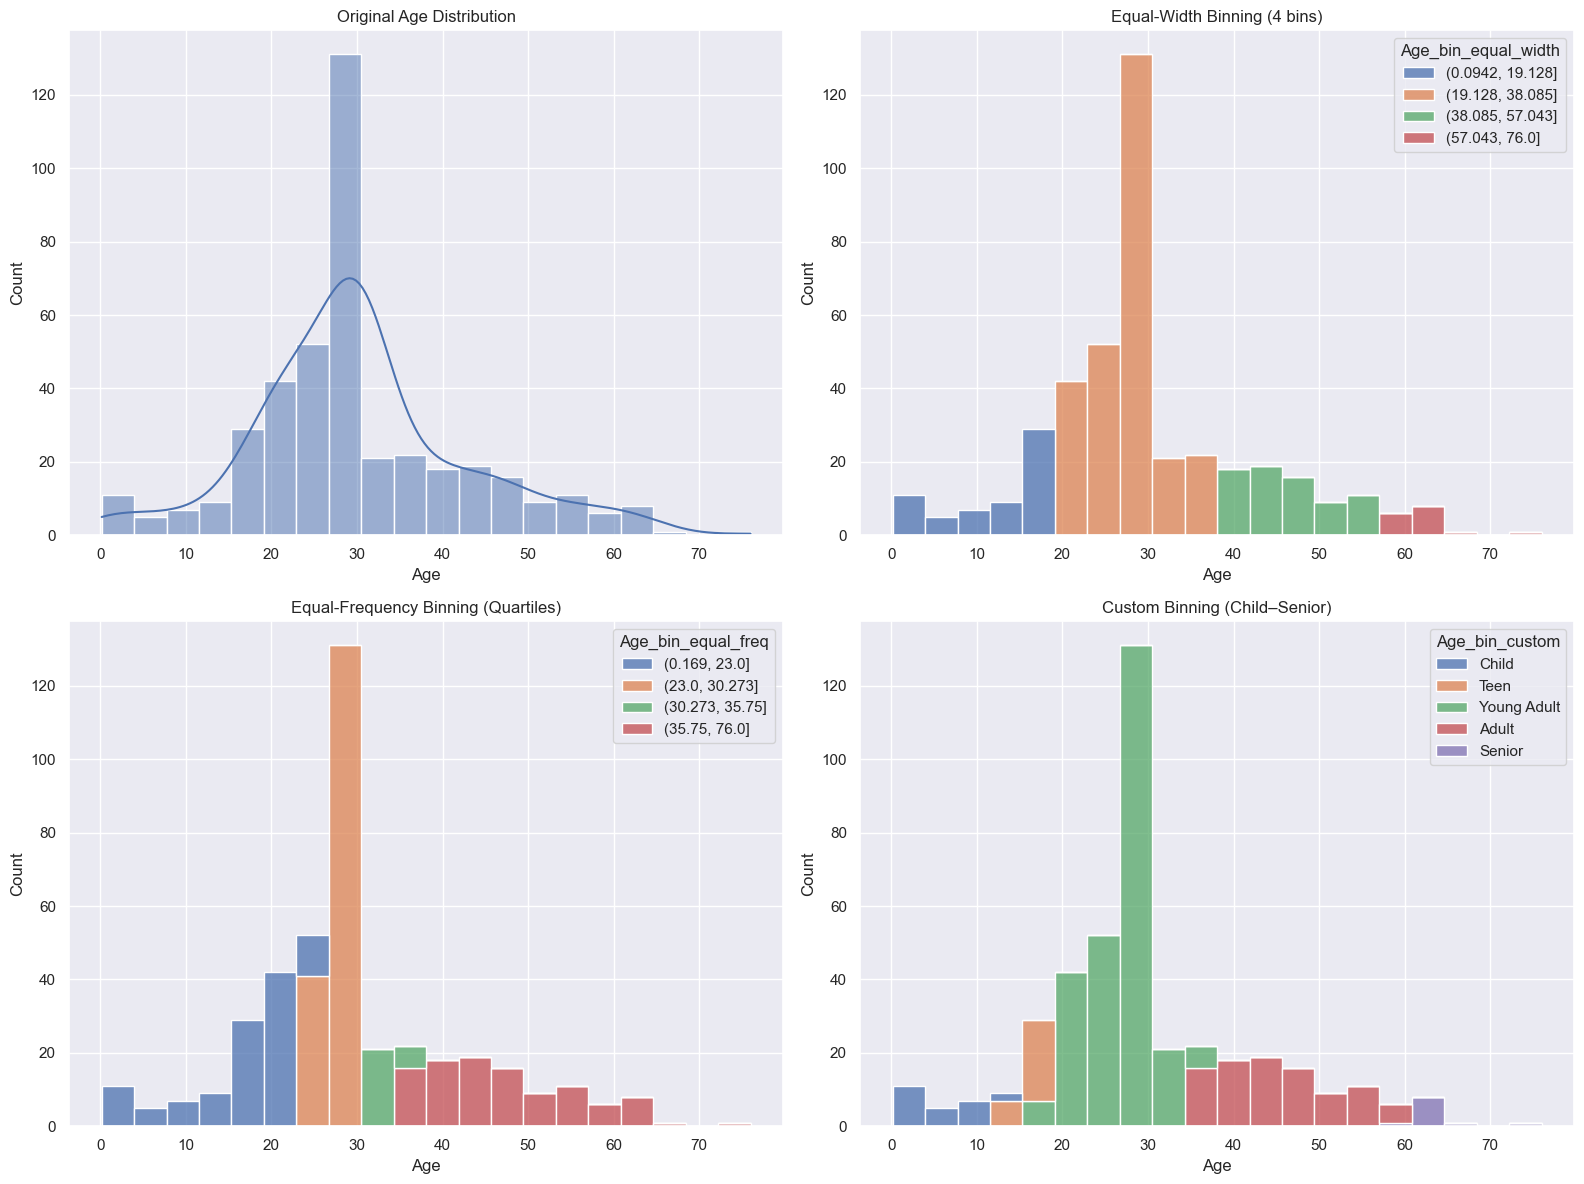

In [15]:
# Equal-Width Binning
titanic_data["Age_bin_equal_width"] = pd.cut(titanic_data["Age"], bins=4)

# Equal-Frequency Binning
titanic_data["Age_bin_equal_freq"] = pd.qcut(titanic_data["Age"], q=4)

# Custom Binning
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]
titanic_data["Age_bin_custom"] = pd.cut(titanic_data["Age"], bins=bins, labels=labels)

plt.figure(figsize=(16, 12))

# Original Age Distribution
plt.subplot(2, 2, 1)
sns.histplot(titanic_data["Age"], bins=20, kde=True)
plt.title("Original Age Distribution")
plt.xlabel("Age")

# Equal-Width Part
plt.subplot(2, 2, 2)
sns.histplot(titanic_data, x="Age", hue="Age_bin_equal_width", multiple="stack", bins=20)
plt.title("Equal-Width Binning (4 bins)")
plt.xlabel("Age")

# Equal-Frequency Part
plt.subplot(2, 2, 3)
sns.histplot(titanic_data, x="Age", hue="Age_bin_equal_freq", multiple="stack", bins=20)
plt.title("Equal-Frequency Binning (Quartiles)")
plt.xlabel("Age")

# Custom Binning Part
plt.subplot(2, 2, 4)
sns.histplot(titanic_data, x="Age", hue="Age_bin_custom", multiple="stack", bins=20)
plt.title("Custom Binning (Child–Senior)")
plt.xlabel("Age")

plt.tight_layout()
plt.show()

### **Data Reduction**

Data Reduction refers to the process of transforming a large, high-dimensional, or overly detailed dataset into a more compact form while preserving the core information needed for analysis or modeling. In real-world data pipelines, raw data often includes millions of records, thousands of features, redundant variables, noisy signals, and extremely fine-grained logs that are expensive to store, slow to process, and difficult to interpret. High dimensionality can lead to the curse of dimensionality, where models overfit or become unstable, while massive row counts strain memory and increase computation time. Meanwhile, unnecessary precision (such as second-level timestamps or many decimal places) introduces noise rather than value.  

To address these challenges, data reduction aims to remove redundancy, compress structure, simplify representation, and retain only the information that truly matters. The result is a dataset that is smaller, cleaner, more efficient to compute, easier to visualize, and more suitable for both exploratory analysis and downstream machine-learning tasks.

There are three main methods:

#### **Dimensionality Reduction**
##### *Feature selection*
Feature selection aims to keep only the most relevant original features by removing redundant, irrelevant, or noisy variables. It is effective because many real-world datasets contain correlated features or attributes that contribute little to prediction, and eliminating them reduces overfitting, improves generalization, and simplifies computation. Common approaches include filter methods such as correlation, chi-square, or mutual information; wrapper methods like recursive feature elimination; and embedded methods such as L1 regularization or tree-based importance. These techniques help retain the most meaningful signals while reducing the overall feature space.
##### *Feature extraction*
Feature extraction transforms the original high-dimensional data into a smaller set of new features that capture the main structure or variance of the dataset. This works well because real-world data often lies on a lower‐dimensional manifold, meaning most of its variability can be represented with far fewer dimensions. Techniques like PCA, SVD, random projection, or t-SNE compress correlated features, denoise the data, and reveal latent structure. The resulting components are more compact and informative, allowing faster computation and improved pattern recognition.

#### **Numerosity Reduction**
##### *Sampling*

Sampling reduces the number of records by selecting a smaller subset that still reflects the original dataset’s distribution. It is effective because many large datasets contain redundant observations or repeated patterns, and statistical properties can often be captured with far fewer samples. Methods like simple random sampling, stratified sampling, or systematic sampling ensure that important groups or classes remain properly represented. With fewer rows, computations become significantly faster while retaining analytical validity.

##### *Aggregation*  

Aggregation compresses fine-grained data by grouping multiple records into higher-level summaries, such as converting second-level logs into hourly statistics or merging transaction-level data into customer-level profiles. This is effective because many analyses do not require extremely detailed records; the aggregated values often carry more stable signals and reduce noise from individual events. By summarizing with metrics like counts, averages, or totals, aggregation produces a smaller, cleaner dataset that better aligns with typical analytical or modeling tasks.

##### *Clustering-Based Reduction*

Clustering-based reduction groups similar records and represents each group with a prototype, such as a centroid or medoid. This works because large datasets often contain many observations that are close to each other in feature space, meaning they contribute redundant information. Clustering identifies this internal structure, allowing the dataset to be compressed without losing its essential patterns. This method is useful for visualization, anomaly detection, and creating compact representations of large unlabeled datasets.

#### **Precision Reduction**
##### *Numerical Precision Reduction*

Numerical precision reduction decreases unnecessary detail in continuous variables—for example, rounding decimals, downsampling pixel resolution, or simplifying timestamps from seconds to minutes. It is effective because many fine-grained values contain measurement noise rather than meaningful signal, and higher precision rarely improves predictions. By reducing precision, the dataset becomes less noisy, more stable, smaller in size, and easier to process, while still preserving the trends that matter.

##### *Discretization / Binning*

Discretization converts continuous variables into intervals or categories, such as age groups or income brackets. This is effective because continuous values often contain noise or minor fluctuations that do not affect the overall pattern, and grouping them creates more robust, interpretable features. Techniques like equal-width bins, equal-frequency bins, or supervised binning help stabilize the data, reduce model sensitivity to outliers, and support algorithms that work better with categorical inputs, such as Naive Bayes or rule-based models.

### **Data Enrichment**

Data Enrichment is the process of enhancing the original dataset by integrating additional information or generating new features that provide stronger context, clearer structure, and higher information value. Raw data collected from systems—such as logs, transactions, or sensor streams—often lacks semantic detail: it may include IDs, timestamps, and simple numeric values, but misses important contextual attributes like demographic profiles, geographic metadata, behavioral summaries, or external environmental factors. Enrichment is important because it transforms low-density raw inputs into high-information features that are easier for analytical tools and machine-learning models to understand. By augmenting the dataset with internal sources, external signals, engineered attributes, or statistical summaries, enrichment helps models learn more stable and generalizable patterns. As a result, data enrichment is often the step that most directly improves the expressive power and predictive performance of a dataset.

#### *Internal Data Integration*

Internal data integration enriches the main dataset using additional information from other tables or systems within the same organization. This includes user profiles, product metadata, historical transactions, or marketing information. The goal is to combine fragmented internal data into a unified, semantically meaningful dataset.

The primary mechanism is relational joining (based on keys such as user_id, product_id, or timestamps). Care must be taken to handle mismatched identifiers, duplicated rows, and potential inconsistencies after merging.

Internal sources usually contain strong domain-related context that raw logs or event data lack. Integrating these sources produces richer features—such as demographic attributes, product categories, or customer-level signals—that enable more meaningful downstream analysis.

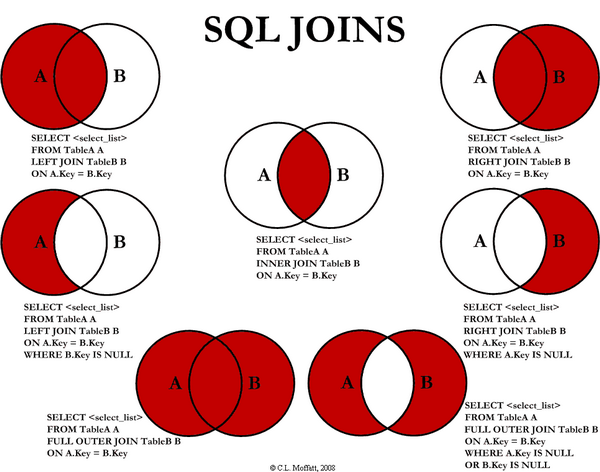

#### *External Data Enrichment*

External enrichment brings in information from outside the primary system, such as public datasets, web APIs, geospatial services, economic indicators, or weather databases. These external factors often explain variations in user behavior or business outcomes that cannot be inferred from internal logs alone.

Common techniques include querying REST APIs, ingesting public CSV/JSON files, performing reverse geocoding, aligning data by time or location, and managing units or formats. After extraction, external fields must be normalized (e.g., timezone alignment, categorical mapping) before merging.

#### *Feature Engineering*

Derived features are engineered from existing columns through mathematical transformations, logical decomposition, or context-aware processing. This step extracts latent structure from raw variables and converts them into features that better align with the true underlying patterns. Raw data rarely presents clear patterns in its original form. Derived features expose hidden structure, reduce noise, and turn continuous streams into meaningful, model-friendly signals.

#### *Aggregation-based Enrichment*

Aggregation summarises historical behaviors or repeated events into stable, entity-level features such as user-level, item-level, or session-level statistics. These aggregated metrics are often far more predictive than individual events because they represent long-term patterns rather than isolated observations. Techniques include groupby aggregations, rolling windows for time-series data, and cross-group statistics (e.g., user-category averages).

Historical summaries are more robust to noise and provide aggregated patterns—such as recency, frequency, intensity, or volatility—that are crucial for recommendation systems, forecasting, and risk modeling.

#### *Model-based Enrichment*

Model-based enrichment uses machine-learning models to generate new feature signals. This includes clustering labels, anomaly scores, embedding vectors, topic distributions, or latent representations learned from deep models. Models can detect patterns not easily defined by manual rules. Embeddings and latent vectors capture semantic or structural relationships within data, enabling richer representations and often delivering strong boosts to predictive performance.

Common enrichment models include:

- K-means, DBSCAN → cluster IDs
- PCA, autoencoders → compressed representations
- Sentence-BERT, word embeddings → semantic vectors
- Isolation Forest, LOF → anomaly scores

### **Data Validation**

Data Validation refers to the process of systematically checking whether a dataset is accurate, consistent, complete, and logically coherent before it is used for analysis or modeling. Real-world data often contains issues originating from ingestion errors, system bugs, human input mistakes, schema changes, or merging inconsistencies. These issues may include incorrect data types, missing or malformed values, impossible ranges, duplicated records, category mismatches, or contradictions between related fields. Without validation, such errors propagate downstream and can lead to misleading insights, unstable models, or failed processing pipelines.

#### *Schema Validation*

Schema validation ensures that the dataset conforms to the expected structural definition, including correct data types, required fields, unique keys, and valid formats. This method is effective because many errors originate from inconsistent typing, malformed strings, incorrect date formats, or missing mandatory fields during ingestion or ETL processes. Common checks include verifying integer/string types, enforcing primary-key uniqueness, validating email/phone formats, and ensuring that essential columns are present. Schema validation is typically implemented through automated rules or contracts that run at the beginning of the data pipeline.

#### *Range Validation*

Range validation checks whether numerical values fall within expected, reasonable, or business-defined boundaries. Since raw data often contains outliers caused by sensor malfunction, manual input errors, or system issues, range checks help capture impossible or unlikely values before they propagate downstream. This includes validating age ranges, percentage bounds, geographic coordinates, rating scores, and monetary limits.

#### *Logical Validation*

Logical validation ensures that the relationships between fields follow consistent business rules or real-world constraints. Even if individual fields are valid, inconsistencies across columns may still indicate errors—for example, an end_time earlier than start_time, a negative order quantity, or a refunded order with a positive amount. Logical validation detects contradictions that simple type or range checks cannot catch.

#### *Cross-Table Validation*

Cross-table validation verifies consistency and referential integrity across different datasets. When merging logs with user tables, or transactions with product catalogs, mismatched IDs, missing references, inconsistent categories, or conflicting attributes indicate upstream issues. Common checks include verifying foreign keys, ensuring that all user_id values in logs appear in the user master table, and detecting duplicated entity definitions.

#### *Distribution Validation*

Distribution validation examines whether the statistical distribution of new data matches historical or expected patterns. This is critical for detecting data drift, pipeline failures, or unexpected shifts in source systems. Key metrics include mean and variance changes, category proportion changes, shifts in quantiles, and deviations detected using statistical tests such as the Kolmogorov–Smirnov (KS) test or chi-square test.

#### *Completeness and Missing-Value Validation*

This method verifies that essential fields are present and evaluates the completeness of the dataset. Missing values often indicate upstream extraction issues, API failures, or incomplete system logs. Checks include ensuring that required columns are non-null, identifying columns with unexpectedly high missing ratios, and detecting empty rows or placeholder values.

#### *Uniqueness and Duplicate Detection*

Uniqueness validation ensures that identifiers such as user_id, session_id, or order_id do not contain unintended duplicates. Duplication impacts aggregations, metrics, and model patterns, especially in transactional or behavioral datasets. Detecting duplicates can reveal ingestion errors, repeated API events, or reprocessing issues.

#### *Domain Validation*

Domain validation checks whether categorical values belong to predefined or acceptable sets, such as allowed product categories, valid country codes, supported payment types, or enumerated status values. Unexpected categories often signal schema mismatches, data corruption, or upstream classification errors.